# 08 — Budget & Federal Funding Context

**Goal:** Show the federal funding dependence of the Texas HHS system and contextualize
IDD service funding within the broader Medicaid budget.

**Data Sources:**
- `annual-federal-funds-report-2024.pdf` — HHSC Annual Federal Funds Report (Dec 2024)
- `hhsc_acre_program_funding.csv` — Rate Enhancement program size (SFY 2019-2024)
- `hhsc_acre_wage_history.csv` — Attendant base wage history (2000-2023)

**Key findings (preview):**
- TX HHS system: $49.5B total, 56% from federal funds ($27.4B)
- Medicaid alone: $25.5B = 93% of all federal HHS funds
- HHSC specifically: $26.9B federal of $47.9B total
- Rate Enhancement grew from $199M (2019) to $306M (2024) but with negligible wage impact
- Attendant base wage increased 5 times in 23 years ($5.15 → $10.60)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

df_federal = pd.read_csv(PROCESSED / 'hhsc_federal_funds_summary.csv')
df_funding = pd.read_csv(PROCESSED / 'hhsc_acre_program_funding.csv')
df_wage_hist = pd.read_csv(PROCESSED / 'hhsc_acre_wage_history.csv')

---
## 1. Texas HHS is Majority Federal-Funded (source_observation)

The Texas HHS system spent $49.5B in SFY 2024. Over half — $27.4B (56%) — came from
federal sources. Medicaid alone accounts for $25.5B, or 93% of all federal HHS funding.

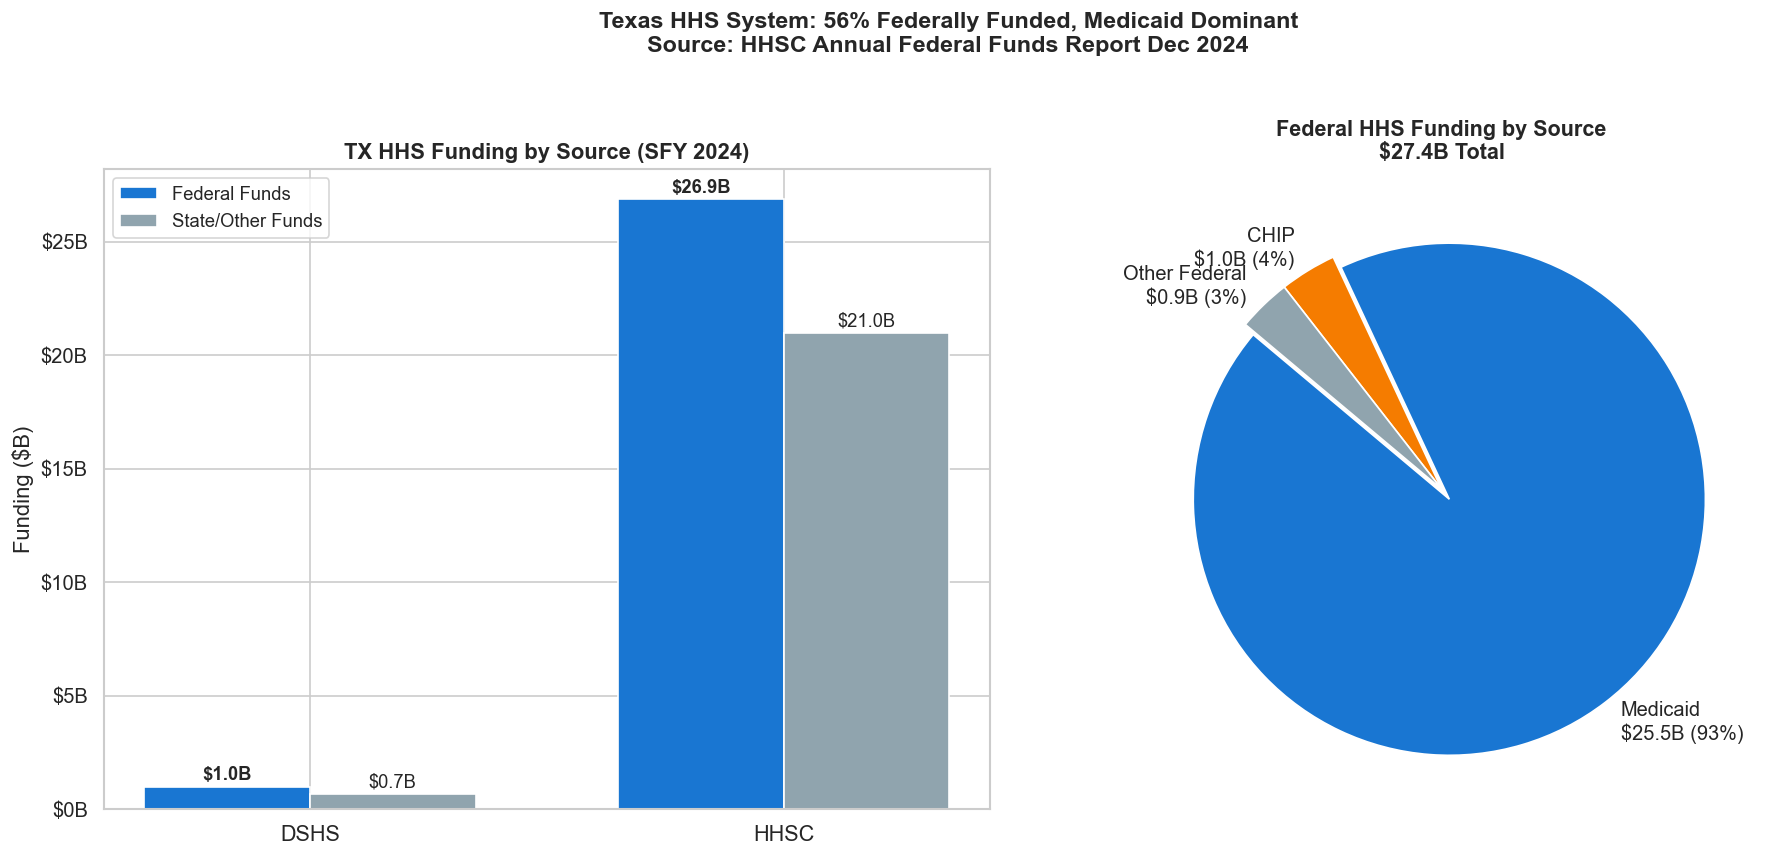

=== Federal Funding Summary (source_observation) ===
  DSHS     Federal: $   1.0B  All: $   1.7B  (60% federal)
  HHSC     Federal: $  26.9B  All: $  47.9B  (56% federal)
  TOTAL    Federal: $  27.9B  All: $  49.5B  (56% federal)

Medicaid: $25.5B = 93% of all federal HHS funding
CHIP: $981.3M = 4% of federal funding


In [2]:
# Federal funding breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Federal vs State funds by agency
agencies = df_federal[df_federal['agency'] != 'TOTAL'].copy()
x = np.arange(len(agencies))
width = 0.35
state_funds = agencies['all_funds'] - agencies['federal_funds']

ax1.bar(x - width/2, agencies['federal_funds'] / 1e9, width,
        label='Federal Funds', color='#1976d2')
ax1.bar(x + width/2, state_funds / 1e9, width,
        label='State/Other Funds', color='#90a4ae')

for i, (_, row) in enumerate(agencies.iterrows()):
    ax1.text(i - width/2, row['federal_funds'] / 1e9 + 0.3,
             f"${row['federal_funds']/1e9:.1f}B", ha='center', fontsize=11,
             fontweight='bold')
    ax1.text(i + width/2, (row['all_funds'] - row['federal_funds']) / 1e9 + 0.3,
             f"${(row['all_funds'] - row['federal_funds'])/1e9:.1f}B",
             ha='center', fontsize=11)

ax1.set_xticks(x)
ax1.set_xticklabels(agencies['agency'].values, fontsize=13)
ax1.set_ylabel('Funding ($B)')
ax1.set_title('TX HHS Funding by Source (SFY 2024)', fontweight='bold')
ax1.legend(fontsize=11)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))

# Right: Medicaid dominance pie
medicaid = 25.5
chip = 0.98
other_fed = 27.4 - medicaid - chip
sizes = [medicaid, chip, other_fed]
labels = [f'Medicaid\n${medicaid:.1f}B (93%)',
          f'CHIP\n${chip:.1f}B (4%)',
          f'Other Federal\n${other_fed:.1f}B (3%)']
colors = ['#1976d2', '#f57c00', '#90a4ae']
explode = (0.05, 0, 0)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='',
        startangle=140, textprops={'fontsize': 12})
ax2.set_title('Federal HHS Funding by Source\n$27.4B Total',
              fontweight='bold', fontsize=13)

plt.suptitle('Texas HHS System: 56% Federally Funded, Medicaid Dominant\n'
             'Source: HHSC Annual Federal Funds Report Dec 2024',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'federal_funding_context.png', bbox_inches='tight')
plt.show()

print("=== Federal Funding Summary (source_observation) ===")
for _, row in df_federal.iterrows():
    print(f"  {row['agency']:<8} "
          f"Federal: ${row['federal_funds']/1e9:>6.1f}B  "
          f"All: ${row['all_funds']/1e9:>6.1f}B  "
          f"({row['pct_federal']:.0%} federal)")
print(f"\nMedicaid: $25.5B = 93% of all federal HHS funding")
print(f"CHIP: $981.3M = 4% of federal funding")

---
## 2. IDD Funding in Context: Rate Enhancement as a Share of Medicaid (derived_estimate)

Rate Enhancement program funding ($306M in SFY 2024) is a tiny fraction of the
$25.5B Medicaid federal spend. Yet these dollars are the primary mechanism for
incentivizing higher wages for IDD direct care workers.

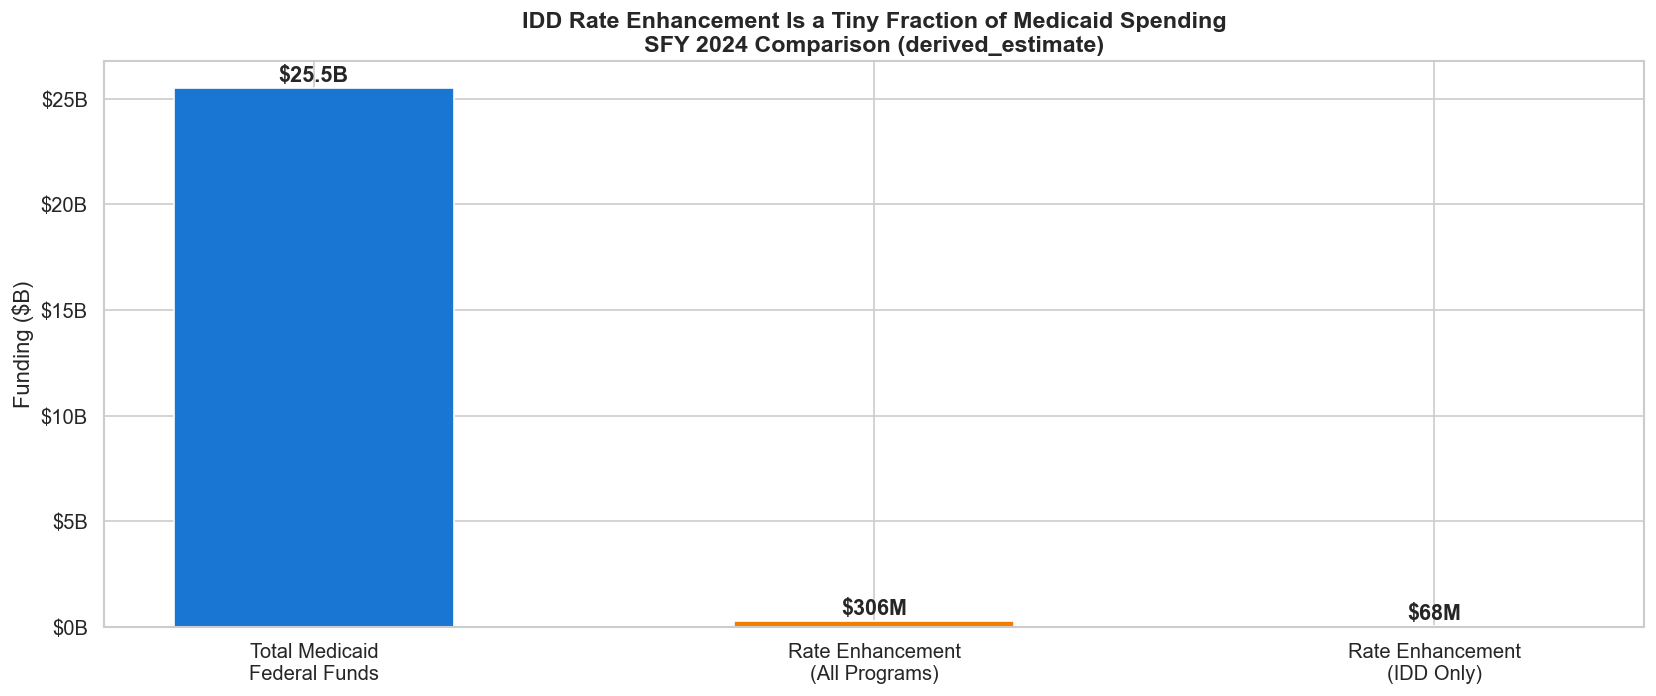

Rate Enhancement (all) as % of Medicaid: 1.20%
Rate Enhancement (IDD) as % of Medicaid: 0.265%

Total RE: $306M
IDD RE:   $68M
Medicaid: $25.5B


In [3]:
# Context: Rate Enhancement vs total Medicaid
medicaid_total = 25_500_000_000
re_total_2024 = df_funding[df_funding['state_fiscal_year'] == 2024]['estimated_program_size'].sum()
re_idd_2024 = df_funding[(df_funding['state_fiscal_year'] == 2024) &
                          (df_funding['provider_type'] == 'IDD Providers')]['estimated_program_size'].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))

# Stacked bar showing scale
categories = ['Total Medicaid\nFederal Funds', 'Rate Enhancement\n(All Programs)',
              'Rate Enhancement\n(IDD Only)']
values = [medicaid_total / 1e9, re_total_2024 / 1e9, re_idd_2024 / 1e9]
colors = ['#1976d2', '#f57c00', '#d32f2f']

bars = ax.bar(categories, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    if val > 1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${val:.1f}B', ha='center', fontweight='bold', fontsize=13)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${val*1000:.0f}M', ha='center', fontweight='bold', fontsize=13)

ax.set_ylabel('Funding ($B)')
ax.set_title('IDD Rate Enhancement Is a Tiny Fraction of Medicaid Spending\n'
             'SFY 2024 Comparison (derived_estimate)',
             fontweight='bold', fontsize=14)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))

plt.tight_layout()
plt.show()

re_pct = re_total_2024 / medicaid_total * 100
idd_pct = re_idd_2024 / medicaid_total * 100
print(f"Rate Enhancement (all) as % of Medicaid: {re_pct:.2f}%")
print(f"Rate Enhancement (IDD) as % of Medicaid: {idd_pct:.3f}%")
print(f"\nTotal RE: ${re_total_2024/1e6:.0f}M")
print(f"IDD RE:   ${re_idd_2024/1e6:.0f}M")
print(f"Medicaid: ${medicaid_total/1e9:.1f}B")

---
## 3. Wage Timeline: Federal, State, and Market Wages (derived_estimate)

Combining ACRE wage history, CPI erosion data, and national comparisons into
a single timeline shows the widening gap between Texas's attendant base wage
and what the market actually requires.

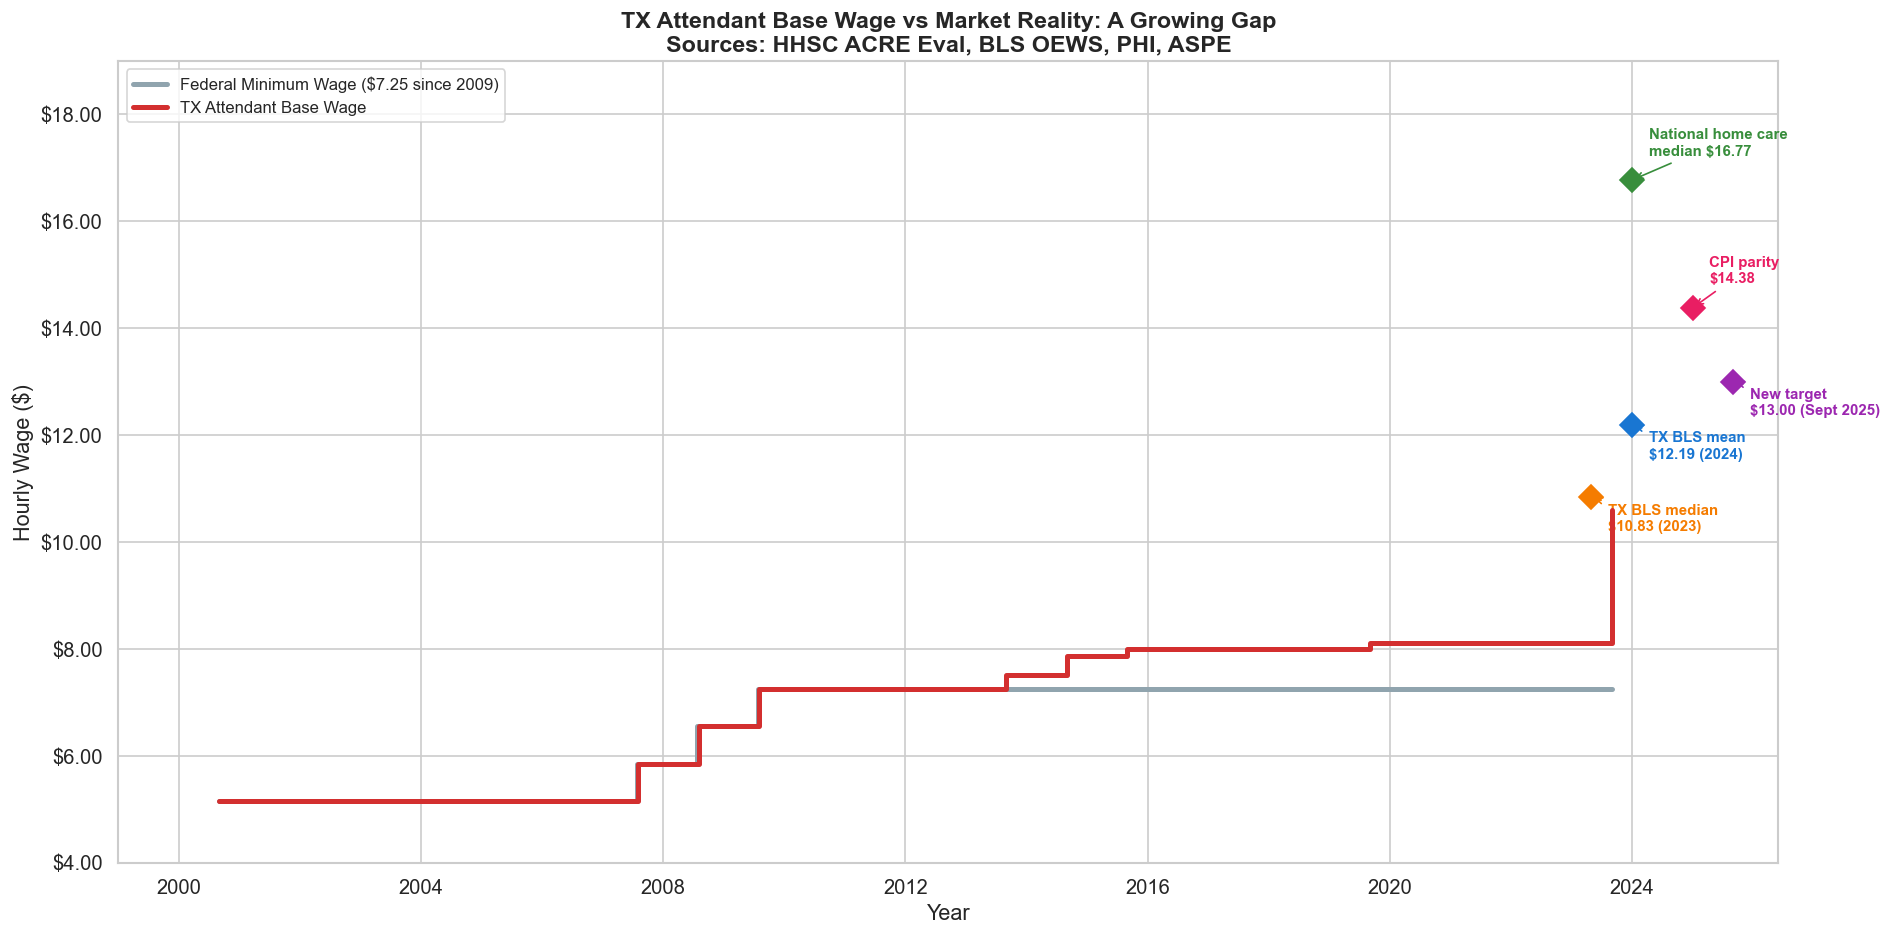

=== Wage Gap Summary (derived_estimate) ===
Federal minimum wage:        $7.25 (frozen since 2009)
TX attendant base (current): $10.60 (since Sept 2023)
TX BLS median (HHA/PCA):     $10.83 (May 2023)
TX BLS mean (HHA/PCA):       $12.19 (May 2024)
New HHSC target:             $13.00 (Sept 2025)
CPI parity:                  $14.38 (2015→2025)
National home care median:   $16.77 (2024)

Gap: New target vs CPI parity: -$1.38/hr
Gap: New target vs national:   -$3.77/hr


In [4]:
# Comprehensive wage timeline
import datetime

fig, ax = plt.subplots(figsize=(16, 8))

df_w = df_wage_hist.copy()
df_w['effective_date'] = pd.to_datetime(df_w['effective_date'])

# Federal minimum wage
ax.step(df_w['effective_date'], df_w['federal_minimum_wage'],
        where='post', linewidth=3, color='#90a4ae',
        label='Federal Minimum Wage ($7.25 since 2009)', zorder=3)

# TX attendant base wage
ax.step(df_w['effective_date'], df_w['attendant_base_wage'],
        where='post', linewidth=3, color='#d32f2f',
        label='TX Attendant Base Wage', zorder=4)

# Key reference points
markers = [
    (datetime.datetime(2023, 5, 1), 10.83, '#f57c00', 'TX BLS median\n$10.83 (2023)'),
    (datetime.datetime(2024, 1, 1), 12.19, '#1976d2', 'TX BLS mean\n$12.19 (2024)'),
    (datetime.datetime(2024, 1, 1), 16.77, '#388e3c', 'National home care\nmedian $16.77'),
    (datetime.datetime(2025, 9, 1), 13.00, '#9c27b0', 'New target\n$13.00 (Sept 2025)'),
    (datetime.datetime(2025, 1, 1), 14.38, '#e91e63', 'CPI parity\n$14.38'),
]

for dt, wage, color, label in markers:
    ax.plot(dt, wage, 'D', color=color, markersize=10, zorder=5)
    offset = 15 if wage > 13 else -20
    ax.annotate(label, xy=(dt, wage), xytext=(10, offset),
                textcoords='offset points', fontsize=9, fontweight='bold',
                color=color, ha='left',
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Hourly Wage ($)', fontsize=13)
ax.set_title('TX Attendant Base Wage vs Market Reality: A Growing Gap\n'
             'Sources: HHSC ACRE Eval, BLS OEWS, PHI, ASPE',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.2f}'))
ax.set_ylim(4, 19)
ax.set_xlim(datetime.datetime(1999, 1, 1), datetime.datetime(2026, 6, 1))

plt.tight_layout()
plt.savefig(REPORTS / 'wage_timeline_comprehensive.png', bbox_inches='tight')
plt.show()

print("=== Wage Gap Summary (derived_estimate) ===")
print(f"Federal minimum wage:        $7.25 (frozen since 2009)")
print(f"TX attendant base (current): $10.60 (since Sept 2023)")
print(f"TX BLS median (HHA/PCA):     $10.83 (May 2023)")
print(f"TX BLS mean (HHA/PCA):       $12.19 (May 2024)")
print(f"New HHSC target:             $13.00 (Sept 2025)")
print(f"CPI parity:                  $14.38 (2015→2025)")
print(f"National home care median:   $16.77 (2024)")
print(f"\nGap: New target vs CPI parity: -$1.38/hr")
print(f"Gap: New target vs national:   -$3.77/hr")

---
## 4. Key Findings

| Finding | Value | Type | Source |
|---------|-------|------|--------|
| TX HHS total spending | $49.5B | source_observation | Fed Funds Report Fig 1 |
| Federal share of HHS | 56% ($27.4B) | source_observation | Fed Funds Report Fig 1 |
| HHSC federal funds | $26.9B | source_observation | Fed Funds Report Fig 1 |
| Medicaid share of federal | 93% ($25.5B) | source_observation | Fed Funds Report p.1 |
| Rate Enhancement (all, SFY 2024) | $306M | source_observation | ACRE Eval Table 1 |
| Rate Enhancement (IDD, SFY 2024) | $68M | source_observation | ACRE Eval Table 1 |
| RE as % of Medicaid | ~1.2% | derived_estimate | $306M / $25.5B |
| IDD RE as % of Medicaid | ~0.27% | derived_estimate | $68M / $25.5B |
| Attendant base wage increases | 5 in 23 years | source_observation | ACRE Eval Table 5 |
| New target vs CPI parity gap | -$1.38/hr | derived_estimate | $13.00 vs $14.38 |
| New target vs national median gap | -$3.77/hr | derived_estimate | $13.00 vs $16.77 |

**Bottom line:** Texas HHS is a $49.5B system, majority federally funded, with Medicaid
accounting for 93% of federal dollars. Yet the specific mechanism for increasing IDD
worker wages — the Rate Enhancement program — represents barely 1% of Medicaid spending.
The IDD portion ($68M) is 0.27% of Medicaid. This is not a resource constraint — it is a
priority choice. The new $13.00 target still falls $1.38/hr short of inflation catch-up
and $3.77/hr short of the national home care median.